# Section: Migrating RoPeR

This notebook is where we put everything together. We combine the velocity model from /determining_a_velocity_model, and the preprocessed section from /RoPeR_preprocessing to get a full image. This notebook will:
1. Walk through the preamble to get the data and all the necesary constants (this is the excact same as in /determining_a_velocity_model and /RoPeR_preprocessing)
2. Import the velocty model and preprocessed data
3. characterize the source wavelet using self-detections
4. Migrate:
   - Method 1: Kirchhoff standard
   - FWI (RTM)

# Import our in-house package and dependencies
Should install relevant dependencies if there is a conflict

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from pds4_tools.reader.core import pds4_read
from tqdm import tqdm

sys.path.append('../..')

import RoPeR
from RoPeR import bandpass, bgr, energy_eq, gain, prestitch
import SimulatingGPR.gprsim as gprsim

/Users/coltenrodriguez/anaconda3/lib/python3.10/site-packages/bruges/__init__.py:20: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


## Need to check out the data to get reelvant constants, but we can ompit all the preprocessing

In [2]:
'''
Retrieving files and sorting them
'''
n, m = 0, 109 # 0-109, load all 109 files
data_dir = '/Users/coltenrodriguez/Desktop/Senior_Thesis/RoPeR_LF' # were data

In [3]:
files = [os.path.join(data_dir, f) for f in os.listdir(data_dir) if '.2CL' in f]
files = sorted(files, key=lambda f: int(f[-10:-6]))[n:m]
length = len(files)

sample_depth = {6000:15000, 4000:10000, 2000:5000, 1000:2500} # number of total pixels in either R/I data: nanoseconds penetration
observable_depth_ns = 1200 # Arbitaraty value

In [4]:
from collections import Counter, defaultdict
'''
Check inhomogenous data (e.g. not all files are LF). also get the effective data legnth (to get ns/px)
'''

effective_data_lens = [info[8] for info in [pds4_read(file, quiet=True)[0].data[0] for file in files]] # Just take the metadata associated with the first trace, as each trace in each file will be the same


if len(set(effective_data_lens)) == 1:
    print(f"Input data is homogenous. Effective data length is {effective_data_lens[0]} bytes. \n {effective_data_lens[0]/8} fpn for real data -- {(effective_data_lens[0]/8)/sample_depth[effective_data_lens[0]/8]} px/ns")
    half_length = int(effective_data_lens[0]/8)
    px_per_ns = half_length/sample_depth[effective_data_lens[0]/8]
else:
    print("Inhomogenous data types. Check that all files are LF or have the same effective data length")

Input data is homogenous. Effective data length is 48000 bytes. 
 6000.0 fpn for real data -- 0.4 px/ns


In [5]:
remove_air = 0
'''
Stitching multiple data files together and gathering some preprocessing data for each file
'''
phase = [0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
pixel_distances = []
sample_meta = None
for f, i, j in zip(files, range(0, length), tqdm(range(length-1))): 
    if n<=i<=m:
        fdata = pds4_read(f, quiet=True)[0].data
        if len(set([int.from_bytes(d[6], 'big', signed=False) for d in fdata])) > 1:
            raise Exception("Trigger mode is not homogenously fixed_distance")
        sample_meta = fdata[0] # might be useless
        scan2d = np.array([d[9] for d in fdata])
        real_part_scan2d = np.array(scan2d[:, :half_length]).T[remove_air:, :]
        
        sample_depth_px, real_part_scan2d_depth_adj = prestitch.depth_correction(real_part_scan2d, px_per_ns, observable_depth_ns)
        real_part_scan2d_depth_self_adj, sds = prestitch.remove_self_detection(real_part_scan2d_depth_adj)
        sds = prestitch.phase_correction(sds, phase[i])
        real_part_scan2d_depth_self_phase_adj = prestitch.phase_correction(real_part_scan2d_depth_self_adj, phase[i])
        real_part_scan2d_depth_self_phase_bgr_adj, _ = bgr.remove_bg(real_part_scan2d_depth_self_phase_adj)
        # Assume this is all interpreted
        yaw = np.array([d[23] for d in fdata])
        pos_x = np.array([d[19] for d in fdata])
        pos_y = np.array([d[20] for d in fdata])
        pos_z = np.array([d[21] for d in fdata])
        pixel_distances.append(np.array([int.from_bytes(d[7], 'big', signed=False) for d in fdata])*10e-3)
        if i == n:
            raw = real_part_scan2d_depth_adj
            self_detection = real_part_scan2d_depth_self_adj
            phase_offset = real_part_scan2d_depth_self_phase_adj
            phase_offset_bg = real_part_scan2d_depth_self_phase_bgr_adj
            self_detections = np.array(sds)
            yaws = yaw
            poss_x, poss_y, poss_z = pos_x, pos_y, pos_z
            trace_dist_m = np.sum(np.array([int.from_bytes(d[7], 'big', signed=False) for d in fdata])*10e-3) # Fixed dist trigger is not fixed for all scans, record dist in a way that pulls from the .CL
        else:
            raw = np.concatenate((raw, real_part_scan2d_depth_adj), axis=1)
            self_detection = np.concatenate((self_detection, real_part_scan2d_depth_self_adj), axis=1)
            phase_offset = np.concatenate((phase_offset, real_part_scan2d_depth_self_phase_adj), axis=1)
            phase_offset_bg = np.concatenate((phase_offset_bg, real_part_scan2d_depth_self_phase_bgr_adj), axis=1)
            self_detections = np.concatenate((self_detections, sds), axis=1)
            yaws = np.concatenate((yaws, yaw))
            poss_x, poss_y, poss_z = np.concatenate((poss_x, pos_x)), np.concatenate((poss_y, pos_y)), np.concatenate((poss_z, pos_z))
            trace_dist_m+=np.sum(np.array([int.from_bytes(d[7], 'big', signed=False) for d in fdata])*10e-3)
            

100%|███████████████████████████████████████████████████████████████| 107/107 [00:14<00:00,  7.42it/s]


In [6]:
def meters_to_pixels(meter_interval, pixel_distances):
    start_m, end_m = meter_interval

    # cumulative distance to the start of each pixel
    cumulative_m = np.concatenate(([0], np.cumsum(pixel_distances)))

    # find pixel indices
    start_pixel = np.searchsorted(cumulative_m, start_m, side="left")
    end_pixel = np.searchsorted(cumulative_m, end_m, side="right") - 1

    # clamp to valid range
    start_pixel = max(0, min(start_pixel, len(pixel_distances) - 1))
    end_pixel = max(0, min(end_pixel, len(pixel_distances) - 1))

    return start_pixel, end_pixel
    
def norm2d(array):
    min_val = np.min(array)
    max_val = np.max(array)
    
    # Apply the normalization formula
    normalized_array = 2 * ((array - min_val) / (max_val - min_val)) - 1
    
    return normalized_array

def zoom(array, bounds):
    # Bounds in [left, right, bottom, top]
    # [:, :], Col slice (vertical), rows slice (horiz), row slice should be left:right, byut col slice should be bottom:top
    '''
    Bounds should be specified as:

                Left: Left coordinate (in meters)
                Right: Right coord (in meters)
                Top: stratigraphic bottom, the larger twt (in ns)
                Bottom: stratigraphic top, the smaller twt (in ns)

    This way bounds may be passed as an arg to plt without modification to show true (phyiscal) position 
    '''
    left, right = meters_to_pixels((bounds[0], bounds[1]), np.concatenate(pixel_distances).ravel())
    return array[int(bounds[3]*0.4):int(bounds[2]*0.4), left:right], bounds
    

# load the preprocessed data and the velocity model

7.99074368384418 2.3758668904093696


(Text(0, 0.5, 'pixels'), Text(0.5, 0, 'pixels'))

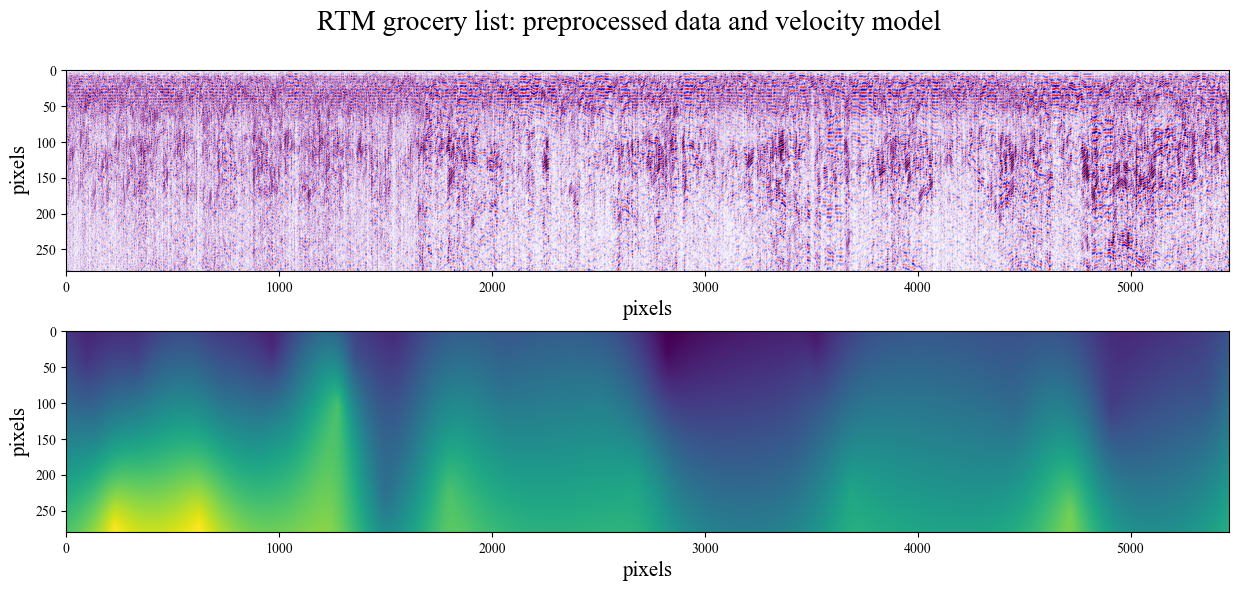

In [21]:
plt.style.use('default')
plt.rcParams.update({
    'font.family': 'serif',  # Often a default in MATLAB
    'font.serif': ['Times New Roman'],
    'axes.labelsize': 15,
    'axes.titlesize': 20,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'lines.linewidth': 1.5,
    'lines.marker': 'o',  # Example marker, adjust as needed
    'grid.linestyle': ':',
    'grid.linewidth': 0.5,
    'axes.grid': False,
    'figure.subplot.wspace': 0,  # Example: Increase horizontal spacing
    'figure.subplot.hspace': 0.3,  # Example: Increase vertical spacing
    'figure.figsize': (14, 4) # Adjust figure size
})

p = np.load('/Users/coltenrodriguez/Desktop/GPR-modeling/Sections/determining_a_velocity_model/preprocessed_data.npy')
# print(p.shape)
# p = phase_offset_bg[int(200*px_per_ns):, :5551]
min_x, max_x = 0, 1800
min_t, max_t = 0, 700
preprocessed_data, bounds = zoom(p, [min_x, max_x, max_t, min_t])

vel_model = np.load('/Users/coltenrodriguez/Desktop/GPR-modeling/Sections/RoPeR_migration/velocity_model.npy')
print(vel_model.max(), vel_model.min())

fig, axs = plt.subplots(2, figsize=(15,6))
fig.suptitle('RTM grocery list: preprocessed data and velocity model', fontsize=20)
axs[0].imshow(preprocessed_data, cmap='seismic', aspect='auto', vmax=preprocessed_data.max()*0.40, vmin=preprocessed_data.min()*0.40)
axs[0].set_ylabel('pixels'), axs[0].set_xlabel('pixels')
axs[1].imshow(vel_model, aspect='auto')
axs[1].set_ylabel('pixels'), axs[1].set_xlabel('pixels')


## Characterizing the source wavelet

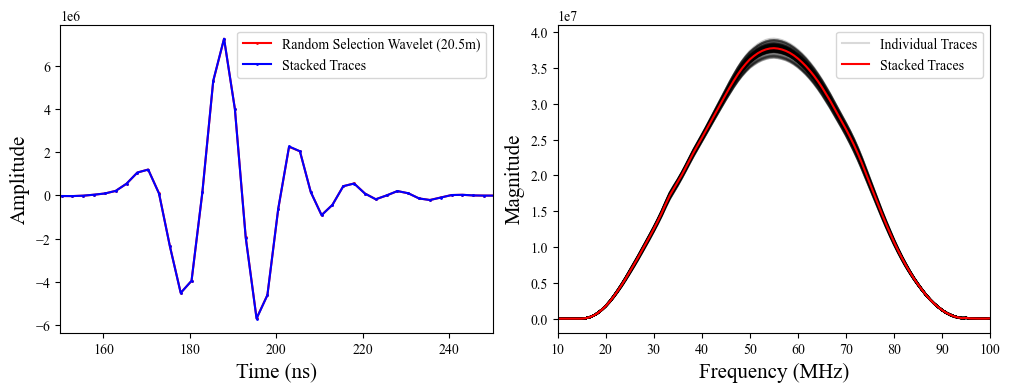

In [22]:
fig, axs = plt.subplots(1, 2, figsize=(12,4))
fig.subplots_adjust(wspace=0.15)
'''
time-space
'''
axs[0].set_ylabel('Amplitude'), axs[0].set_xlabel('Time (ns)'), axs[0].set_xlim(150, 250)
random_wavelet = self_detections[:, 20]
stacked_wavelet = np.mean(self_detections, axis=1)
axs[0].plot(np.linspace(0,1200, self_detections.shape[0]), random_wavelet, label='Random Selection Wavelet (20.5m)', c='red', markersize=1)
axs[0].plot(np.linspace(0,1200, self_detections.shape[0]), stacked_wavelet, label='Stacked Traces', c='blue', markersize=1)
axs[0].legend()


'''
Frequency Space. Taking the FT of each trace and averaging them
'''
freq_space_im = []
for i, trace in enumerate(self_detections.T):
    x = np.array(trace)       # your 1D waveform
    n = len(x)
    
    # Sampling interval (seconds)
    dt = 2.5e-9           # 2.5 ns
    
    # FFT
    X = np.fft.fft(x)
    
    # Frequency axis
    freq = np.fft.fftfreq(n, d=dt)

    # Magnitude spectrum
    magnitude = np.abs(X)
    freq_space_im.append(magnitude)
    
    pos_mask = freq >= 0
    axs[1].plot(freq[pos_mask] * 1e-6, magnitude[pos_mask], color='black', alpha=0.2, markersize=0)

    

magnitude = np.array(freq_space_im).T.mean(axis=1)
pos_mask = freq >= 0
axs[1].plot(freq[pos_mask] * 1e-6, magnitude[pos_mask], color='black', alpha=0.15, markersize=0, label='Individual Traces')
axs[1].plot(freq[pos_mask] * 1e-6, magnitude[pos_mask], color='red', markersize=0, label='Stacked Traces'), axs[1].set_xlim(10, 100)
axs[1].set_xlabel('Frequency (MHz)'), axs[1].set_ylabel('Magnitude')
axs[1].legend()

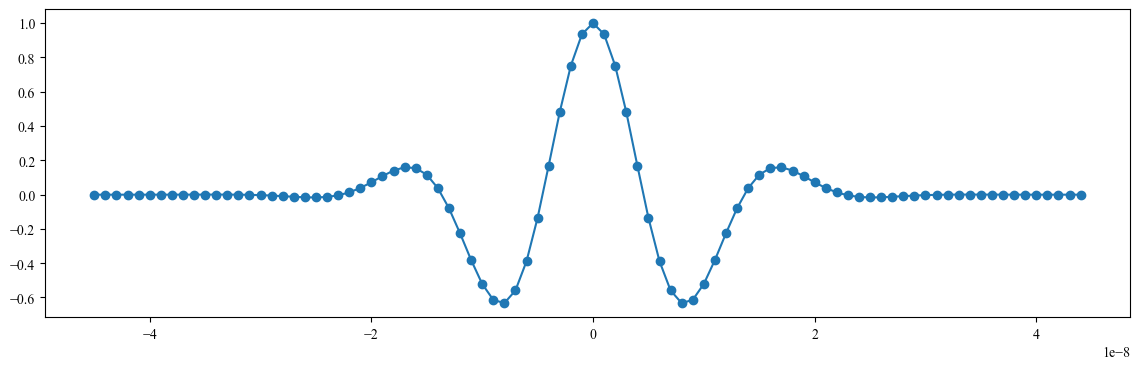

In [23]:
import numpy as np

def gaussian_bandlimited_wavelet(
    f0,
    bw_2sigma,
    dt,
    n,
    phase=0.0,
    bw_2sigma_is_fullwidth=False,
    normalize=True
):

    # Frequency grid for real FFT
    f = np.fft.rfftfreq(n, d=dt)

    # Convert "2 sigma" bandwidth into sigma_f
    if bw_2sigma_is_fullwidth:
        # bw_2sigma = 4*sigma_f  => sigma_f = bw_2sigma/4
        sigma_f = bw_2sigma / 4.0
    else:
        # bw_2sigma = 2*sigma_f  => sigma_f = bw_2sigma/2
        sigma_f = bw_2sigma / 2.0

    # Gaussian amplitude spectrum centered at f0
    A = np.exp(-0.5 * ((f - f0) / sigma_f) ** 2)

    # Optional constant phase
    W = A * np.exp(1j * phase)

    # Inverse real FFT -> real time-domain wavelet
    w = np.fft.irfft(W, n=n)

    # Center the wavelet in time (so peak is near t=0)
    w = np.fft.fftshift(w)
    t = (np.arange(n) - n // 2) * dt

    if normalize:
        w /= np.max(np.abs(w)) + 1e-12

    return t, w, f, W

dt = 1e-9          # 1 ns sampling
n  = 90
f0 = 5.5e7          # 55Mhz center frequency
bw_2sigma = 3.5e7   # interpret as 2*sigma_f = 70MHz

t, w, f, W = gaussian_bandlimited_wavelet(f0, bw_2sigma, dt, n)
plt.plot(t, w)

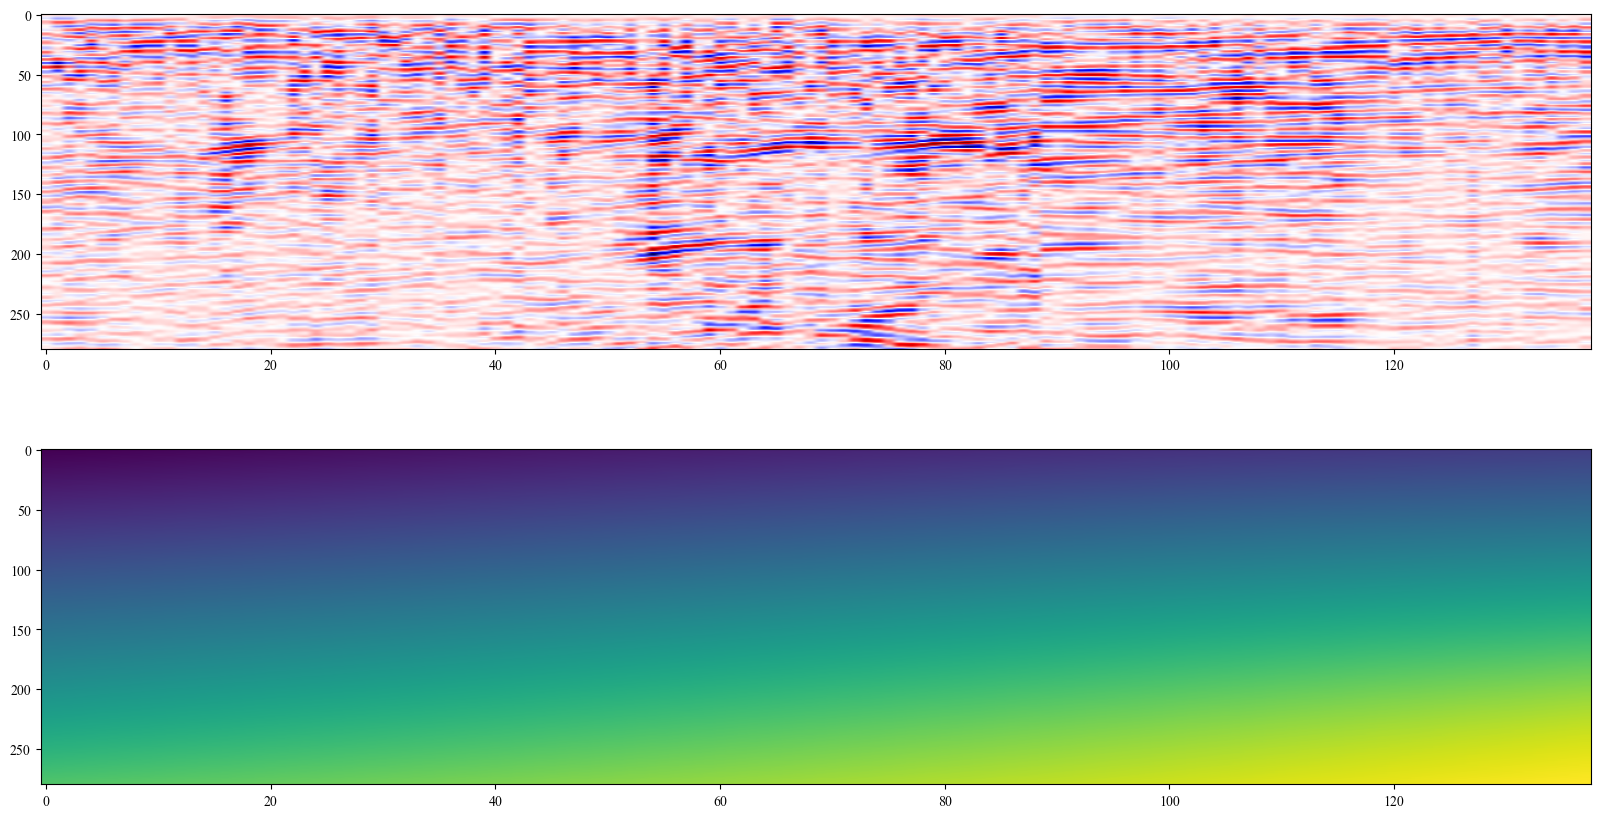

In [218]:
min_x, max_x = 800, 869
min_t, max_t = 0, 700
radargram, bounds = zoom(p, [min_x, max_x, max_t, min_t])
eps, _ = zoom(vel_model, [min_x, max_x, max_t, min_t])
cmap = plt.get_cmap('seismic')
rgb_img = cmap(radargram)[:,:,0]
fig, axs = plt.subplots(2, figsize=(20,10))
axs[0].imshow(radargram, cmap="seismic", aspect='auto')
axs[1].imshow(eps, aspect='auto')


## Constants for RTM

The three big peices that we now have are the velocity model, the preprocessed gpr section, and the wave. We also need:

| Parameter | What is it? |
|---|---|
| dx | The horizontal resolution of the velocity model: how many meters per pixel? |
| dz | The vertical resolution of the velocity model: How many **meters** per pixel. This is an important point to make as the vertical step size up to now has typically been dt. we'll have to estimate dz. Thankfully we already have a function that does this, just modify depth_of_penetration() slightly from its implementation in Quantifying_migration_uncertainty.ipynb|
| dt | how many pixels per ns, thisi s just 1/px_per_ns defined above |
| shot_positions | something |

We need to be careful not violate CFL condition in FWI, so we have to downsample the velocity model. This is fine, its an interpolated product anyway and the other option --- upsampling the radargram --- is something I'd like to stay away from doing to keep this an honest method.

## RTM

In [221]:
from bruges.filters.wavelets import ricker
from SimulatingGPR import migration as mig
import skimage

c0 = 3e8

from scipy.signal import resample
radargram_upsampled = resample(radargram, 1400, axis=0)  # 200 → 1000 samples

'''
Inverse "solution" 3. RTM
'''
data_demeaned = radargram - np.mean(radargram, axis=1, keepdims=True)*0.998

velocity = c0 / np.sqrt(eps.T)
f0 = 5.5e7
dt = 0.5e-9
w, _ = ricker(duration=1.5 / f0, dt=dt, f=f0)
w /= np.max(np.abs(w))

migrated_image_800_869 = gpr_rtm(
    radargram=radargram_upsampled,
    shot_positions=np.arange(138) * 0.5,
    velocity_model=velocity,
    dx=0.5,
    dz=0.125,
    dt=dt,
    source_wavelet=w
    )


Text(0.5, 1.0, 'Migrated Section (FWI)')

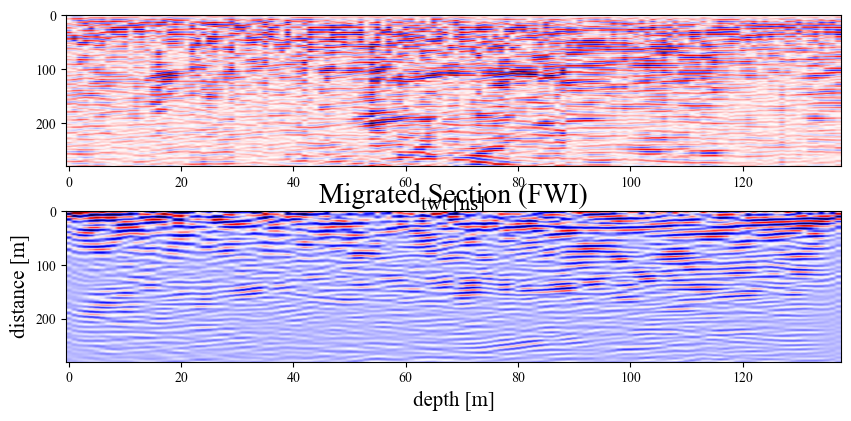

In [222]:
# migrated_image = np.clip(migrated_image.T, a_min=-np.max(np.abs(migrated_image))*0.02, a_max=np.max(np.abs(migrated_image))*0.02)
plt.rcParams.update({
    'figure.figsize': (10, 4.5) # Adjust figure size
})
data_demeaned = radargram - np.mean(radargram, axis=1, keepdims=True)*0.998

fig, axs = plt.subplots(2)

axs[0].imshow(data_demeaned, aspect='auto', vmin=data_demeaned.min()*0.8, vmax=data_demeaned.max()*0.8, cmap='seismic')
axs[0].set_xlabel("twt [ns]"); axs[1].set_ylabel("distance [m]"); axs[1].set_title('GPR section')

axs[1].imshow(migrated_image_800_869.T, aspect='auto', vmin=migrated_image_700_800.min()*0.6, vmax=migrated_image_700_800.max()*0.6, cmap='seismic')
axs[1].set_xlabel("depth [m]"); axs[1].set_ylabel("distance [m]"); axs[1].set_title('Migrated Section (FWI)')


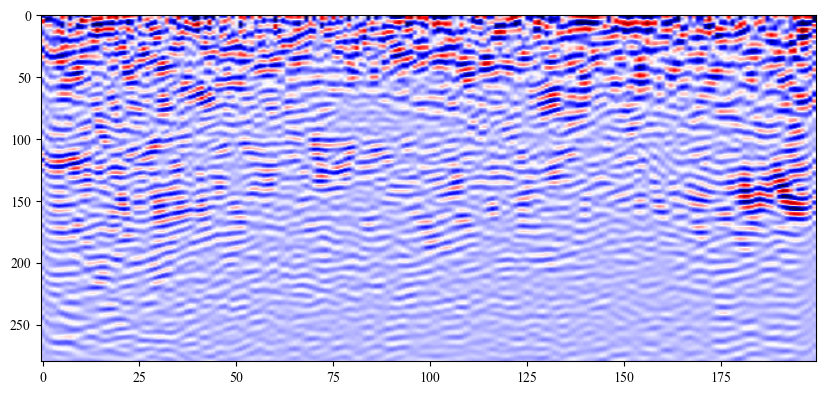

In [217]:
np.save(f'/Users/coltenrodriguez/Desktop/GPR-modeling/Sections/RoPeR_migration/FWI_products/_.npy', product)




In [206]:
os.getcwd()

'/Users/coltenrodriguez/Desktop/GPR-modeling/Sections/RoPeR_migration'

In [151]:
tmax = 700e-9
px_per_ns = 0.4
migrated_kirchhoff = mig.Kichhoff(radargram, np.mean(eps), tmax, int(tmax/((1/px_per_ns)*1e-9)), np.arange(0, tmax, ((1/px_per_ns)*1e-9)), np.arange(0, radargram.shape[1], 1))


Text(0.5, 1.0, 'Migrated Section (Kirchhoff)')

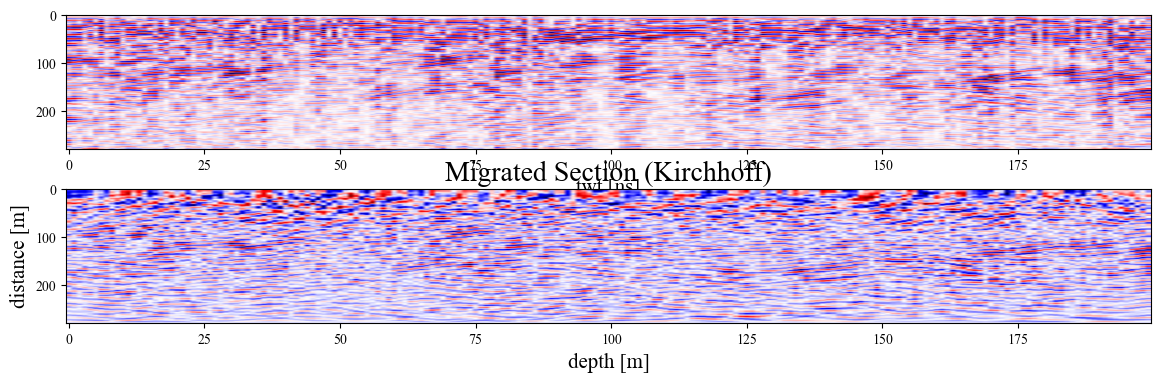

In [156]:
migrated_image_kirchhoff, z = migrated_kirchhoff

fig, axs = plt.subplots(2)

axs[0].imshow(data_demeaned, aspect='auto', vmin=data_demeaned.min()*0.8, vmax=data_demeaned.max()*0.8, cmap='seismic')
axs[0].set_xlabel("twt [ns]"); axs[1].set_ylabel("distance [m]"); axs[1].set_title('GPR section')

axs[1].imshow(migrated_image_kirchhoff.T, aspect='auto', vmin=migrated_image_kirchhoff.min()*0.9, vmax=migrated_image_kirchhoff.max()*0.9, cmap='seismic')
axs[1].set_xlabel("depth [m]"); axs[1].set_ylabel("distance [m]"); axs[1].set_title('Migrated Section (Kirchhoff)')

In [38]:
def gpr_rtm(radargram, shot_positions, velocity_model, dx, dz, dt, source_wavelet):
    
    nt, n_shots = radargram.shape
    nx, nz = velocity_model.shape
    
    # Convert shot positions from meters to grid indices
    shot_indices = np.round(shot_positions / dx).astype(int)
    
    # Initialize image
    image = np.zeros((nx, nz))
    
    # Imaging condition accumulator
    source_energy = np.zeros((nx, nz))
    
    for shot_idx, x_pos in enumerate(shot_indices):

        # === FORWARD PROPAGATION (source wavefield) ===
        u_fwd_prev = np.zeros((nx, nz))
        u_fwd = np.zeros((nx, nz))
        
        # Store forward wavefield for all times
        forward_wavefield = np.zeros((nt, nx, nz))
        
        for it in range(nt):
            # Laplacian
            lap = np.zeros_like(u_fwd)
            lap[1:-1, 1:-1] = (
                (u_fwd[2:, 1:-1] - 2*u_fwd[1:-1, 1:-1] + u_fwd[:-2, 1:-1]) / dx**2 +
                (u_fwd[1:-1, 2:] - 2*u_fwd[1:-1, 1:-1] + u_fwd[1:-1, :-2]) / dz**2
            )
            
            # Time update
            u_fwd_next = 2*u_fwd - u_fwd_prev + velocity_model**2 * dt**2 * lap
            
            # Inject source
            if it < len(source_wavelet):
                u_fwd_next[x_pos, 1] += source_wavelet[it]
            
            # Apply ABCs (same as forward modeling)
            u_fwd_next = apply_abc(u_fwd_next, u_fwd, velocity_model, dx, dz, dt)
            
            # Save wavefield
            forward_wavefield[it] = u_fwd_next.copy()
            
            # Update
            u_fwd_prev, u_fwd = u_fwd, u_fwd_next
        
        # === BACKWARD PROPAGATION (receiver wavefield) ===
        u_bwd_prev = np.zeros((nx, nz))
        u_bwd = np.zeros((nx, nz))
        
        # Time-reverse the recorded trace
        trace_reversed = radargram[:, shot_idx][::-1]
        
        for it in range(nt):
            # Laplacian
            lap = np.zeros_like(u_bwd)
            lap[1:-1, 1:-1] = (
                (u_bwd[2:, 1:-1] - 2*u_bwd[1:-1, 1:-1] + u_bwd[:-2, 1:-1]) / dx**2 +
                (u_bwd[1:-1, 2:] - 2*u_bwd[1:-1, 1:-1] + u_bwd[1:-1, :-2]) / dz**2
            )
            
            # Time update
            u_bwd_next = 2*u_bwd - u_bwd_prev + velocity_model**2 * dt**2 * lap
            
            # Inject receiver data (time-reversed)
            u_bwd_next[x_pos, 1] += trace_reversed[it]
            
            # Apply ABCs
            u_bwd_next = apply_abc(u_bwd_next, u_bwd, velocity_model, dx, dz, dt)
            
            # === IMAGING CONDITION ===
            # Cross-correlate forward and backward wavefields
            # Use time index nt-1-it to get matching forward wavefield
            image += forward_wavefield[nt-1-it] * u_bwd_next
            source_energy += forward_wavefield[nt-1-it]**2
            
            # Update
            u_bwd_prev, u_bwd = u_bwd, u_bwd_next
    
    # Normalize by source energy to reduce artifacts
    source_energy[source_energy < 0.01 * np.max(source_energy)] = 1  # avoid division by zero
    image /= source_energy
    
    return image


def apply_abc(u_next, u, velocity, dx, dz, dt):
    """Apply absorbing boundary conditions"""
    r_x = velocity * dt / dx
    r_z = velocity * dt / dz
    
    # Left
    u_next[0, :] = u[1, :] + (r_x[0, :] - 1) / (r_x[0, :] + 1) * (u_next[1, :] - u[0, :])
    # Right
    u_next[-1, :] = u[-2, :] + (r_x[-1, :] - 1) / (r_x[-1, :] + 1) * (u_next[-2, :] - u[-1, :])
    # Bottom
    u_next[:, -1] = u[:, -2] + (r_z[:, -1] - 1) / (r_z[:, -1] + 1) * (u_next[:, -2] - u[:, -1])
    
    return u_next

In [119]:
int(300e-9/((1/1)*1e-9))
Tlim=t_max, 
Nt=int(t_max/((1/px_per_ns)*1e-9)), 
t_samples=np.arange(0, t_max, 
((1/px_per_ns)*1e-9)), 
x_positions=np.arange(0, 46, 1)



299

In [ ]:
"""
fial stages:

housekeeping stuff:
1. Update the repo to include hyperbola fitting code and incorperate into velocity model

Actual work:
1. Write the migration RoPeR migration section of the paper, which includes
- Making the hyperbola fitting/velocity model figure and briefly writing about that
- making the stacked plot figure of BOTH Kirchhoff migrated and FWI migrated full sections

2. Write the results section, which includes
- The dip distribution of Kirchhoff compared to RTM
"""